In [1]:
# 定义一个字典，将分类标签映射为中文名称
classification_names = {
    0: '上衣',
    1: '鞋',
    2: '包',
    3: '下身衣服',
    4: '手表'
}

In [11]:
import torch
import os
from PIL import Image
import pandas as pd
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from common.utils import sorted_alphanum

In [7]:
# 自定义数据集类
class ImageLabelDataset(Dataset):
    # 初始化
    def __init__(self, main_dir, label_dir, transform=None):
        self.main_dir = main_dir
        self.transform = transform
        self.imgs = sorted_alphanum( os.listdir(main_dir) )
        # 读取分类标签
        labels = pd.read_csv(label_dir)
        # 将分类标签保存为字典
        self.labels_dict = dict(zip( labels['id'], labels['target']) )
    # 获取长度
    def __len__(self):
        return len(self.imgs)
    # 按照索引号获取元素
    def __getitem__(self, idx):
        # 1. 获取索引号idx对应图片文件路径 
        img_path = os.path.join(self.main_dir, self.imgs[idx])
        # 2. 加载图像数据
        image = Image.open(img_path).convert('RGB')
        # 3. 对图像进行预处理转换
        if self.transform is not None:
            tensor_image = self.transform(image)
        else:
            raise ValueError("transform 参数不能为 None！")
        # 4. 在标签字典中查找对应分类标签
        img_label = self.labels_dict[idx]
        
        return tensor_image, img_label

In [8]:
# 1. 创建数据集
# 定义转换操作
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
])
dataset = ImageLabelDataset('../common/dataset/', label_dir='../common/fashion-labels.csv', transform=transform)
print(len(dataset))

24853


In [9]:
print(dataset.imgs)

['0.jpg', '1.jpg', '2.jpg', '3.jpg', '4.jpg', '5.jpg', '6.jpg', '7.jpg', '8.jpg', '9.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg', '14.jpg', '15.jpg', '16.jpg', '17.jpg', '18.jpg', '19.jpg', '20.jpg', '21.jpg', '22.jpg', '23.jpg', '24.jpg', '25.jpg', '26.jpg', '27.jpg', '28.jpg', '29.jpg', '30.jpg', '31.jpg', '32.jpg', '33.jpg', '34.jpg', '35.jpg', '36.jpg', '37.jpg', '38.jpg', '39.jpg', '40.jpg', '41.jpg', '42.jpg', '43.jpg', '44.jpg', '45.jpg', '46.jpg', '47.jpg', '48.jpg', '49.jpg', '50.jpg', '51.jpg', '52.jpg', '53.jpg', '54.jpg', '55.jpg', '56.jpg', '57.jpg', '58.jpg', '59.jpg', '60.jpg', '61.jpg', '62.jpg', '63.jpg', '64.jpg', '65.jpg', '66.jpg', '67.jpg', '68.jpg', '69.jpg', '70.jpg', '71.jpg', '72.jpg', '73.jpg', '74.jpg', '75.jpg', '76.jpg', '77.jpg', '78.jpg', '79.jpg', '80.jpg', '81.jpg', '82.jpg', '83.jpg', '84.jpg', '85.jpg', '86.jpg', '87.jpg', '88.jpg', '89.jpg', '90.jpg', '91.jpg', '92.jpg', '93.jpg', '94.jpg', '95.jpg', '96.jpg', '97.jpg', '98.jpg', '99.jpg', '100.jpg'

In [10]:
print(dataset.labels_dict)

{0: 3, 1: 3, 2: 3, 3: 0, 4: 3, 5: 0, 6: 0, 7: 0, 8: 3, 9: 0, 10: 3, 11: 0, 12: 3, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 1, 21: 1, 22: 1, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 0, 31: 0, 32: 0, 33: 0, 34: 3, 35: 0, 36: 0, 37: 0, 38: 0, 39: 0, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0, 45: 0, 46: 0, 47: 0, 48: 0, 49: 0, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 4, 61: 1, 62: 1, 63: 1, 64: 4, 65: 4, 66: 4, 67: 4, 68: 4, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 4, 78: 4, 79: 4, 80: 4, 81: 4, 82: 4, 83: 4, 84: 4, 85: 4, 86: 4, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 4, 109: 1, 110: 1, 111: 0, 112: 0, 113: 0, 114: 4, 115: 4, 116: 4, 117: 4, 118: 2, 119: 2, 120: 2, 121: 2, 122: 2, 123: 2, 124: 2, 125: 2, 126: 2, 127: 2, 128: 2, 129: 2, 130: 2, 131: 2, 132: 4, 133: 2, 134: 2, 135: 2, 136: 2, 137: 2, 138: 

In [12]:
# 2. 划分数据集
train_dataset, test_dataset = random_split(dataset, [0.75, 0.25])
print(len(train_dataset))
print(len(test_dataset))

18640
6213


In [23]:
# 3. 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [14]:
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [15]:
import torch.nn as nn
# 自定义分类器神经网络模型
class Classifier(nn.Module):
    # 初始化
    def __init__(self, num_classes=5):
        super().__init__()
        # 两个卷积层
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1)
        # 通用池化层
        self.pool = nn.MaxPool2d(2, 2)
        # 全连接层
        self.linear = nn.Linear(16 * 16 * 16, num_classes)
    # 前向传播
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        print("conv1 out: ", x.shape)
        x = self.pool(x)
        print("pool1 out: ", x.shape)
        x = torch.relu(self.conv2(x))
        print("conv2 out: ", x.shape)
        x = self.pool(x)
        print("pool2 out: ", x.shape)
        x = x.reshape(x.shape[0], -1)   # 将特征图展开为一维向量
        print("reshape1 out: ", x.shape)
        x = self.linear(x)
        return x

In [16]:
# 4. 创建模型
model = Classifier()
print(model)

Classifier(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear): Linear(in_features=4096, out_features=5, bias=True)
)


In [17]:
# 前向传播，进行测试
outputs = model(images)
print(outputs.shape)

conv1 out:  torch.Size([32, 8, 64, 64])
pool1 out:  torch.Size([32, 8, 32, 32])
conv2 out:  torch.Size([32, 16, 32, 32])
pool2 out:  torch.Size([32, 16, 16, 16])
reshape1 out:  torch.Size([32, 4096])
torch.Size([32, 5])


In [18]:
# 另一种定义分类器方式：Sequential
class Classifier(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(),
            nn.Linear(16 * 16 * 16, num_classes)
        )
    def forward(self, x):
        return self.model(x)

In [19]:
model = Classifier()
print(model)

Classifier(
  (model): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=5, bias=True)
  )
)


In [20]:
# 前向传播，进行测试
outputs = model(images)
print(outputs.shape)

torch.Size([32, 5])


In [21]:
# 5. 定义超参数、设备、损失函数、优化器
lr = 0.001
epoch_num = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Classifier(
  (model): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=4096, out_features=5, bias=True)
  )
)

In [22]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [24]:
# 6. 模型训练
model.train()
for epoch in range(epoch_num):
    train_loss = 0.0
    
    for images, labels in train_loader:
        input, target = images.to(device), labels.to(device)
        output = model(input)   # 前向传播
        loss_value = loss(output, target)   # 计算损失
        loss_value.backward()   # 反向传播
        optimizer.step()        # 更新参数
        optimizer.zero_grad()   # 梯度清零
        
        train_loss += loss_value.item()
    
    this_loss = train_loss / len(train_loader)
    print(f"epoch {epoch+1}\t train loss: {this_loss:.6f}")

epoch 1	 train loss: 0.234760
epoch 2	 train loss: 0.084322
epoch 3	 train loss: 0.065112
epoch 4	 train loss: 0.054181
epoch 5	 train loss: 0.046575
epoch 6	 train loss: 0.041069
epoch 7	 train loss: 0.034535
epoch 8	 train loss: 0.030561
epoch 9	 train loss: 0.028854
epoch 10	 train loss: 0.024175


In [25]:
# 7. 测试分类模型
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# 7.1 获取测试集的一个批次数据
data_iter = iter(test_loader)
images, labels = next(data_iter)
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 64, 64])
torch.Size([32])


In [27]:
# 7.2 前向传播，推理预测
images = images.to(device)
outputs = model(images)

In [28]:
# 7.3 数据转换，为画图显示做准备
images = images.permute(0, 2, 3, 1).cpu().numpy()
print(images.shape)

(32, 64, 64, 3)


In [32]:
# 得到预测标签
preds = outputs.argmax(dim=1).detach().cpu().numpy()
print(preds.shape)

(32,)


1-label: 3
1-pred: 0, 预测分类：上衣

2-label: 0
2-pred: 0, 预测分类：上衣

3-label: 1
3-pred: 1, 预测分类：鞋

4-label: 0
4-pred: 0, 预测分类：上衣

5-label: 1
5-pred: 1, 预测分类：鞋

6-label: 1
6-pred: 1, 预测分类：鞋

7-label: 0
7-pred: 0, 预测分类：上衣

8-label: 0
8-pred: 0, 预测分类：上衣

9-label: 1
9-pred: 1, 预测分类：鞋

10-label: 1
10-pred: 1, 预测分类：鞋



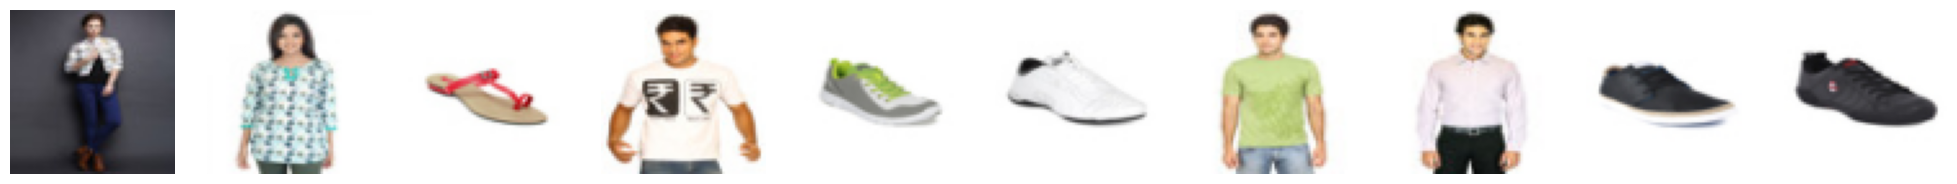

In [33]:
# 7.4 画图和打印输出
fig, axes = plt.subplots(1, 10, figsize=(25, 4), sharex=True, sharey=True)
for i in range(10):
    # 画图
    axes[i].imshow(images[i])
    axes[i].axis('off')
    # 打印真实标签
    print(f"{i+1}-label: {labels[i]}")
    # 打印预测标签
    class_pred = classification_names[ preds[i] ]
    print(f"{i+1}-pred: {preds[i]}, 预测分类：{class_pred}")
    print()

plt.show()

In [34]:
# 计算预测准确率
test_correct_num = 0
with torch.no_grad():
    for images, labels in test_loader:
        input, target = images.to(device), labels.to(device)
        # 前向传播
        output = model(input)
        # 得到预测分类号
        preds = output.argmax(dim=1)
        # 累加预测正确数量
        test_correct_num += preds.eq(target).sum()
test_accuray = test_correct_num / len(test_dataset)
print(f"分类预测准确率：{test_accuray:.6f}")

分类预测准确率：0.986963
